HoF[0] loss: -0.10166373600529077
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_2 ----> X_1 + X_2;  [MAK(0.44269517064094543)]
X_3 ----> ∅;  [MAK(0.1)]
X_3 ----> X_2 + X_2;  [MAK(0.3158538043498993)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.14039254188537598)]
X_2 + X_2 ----> X_1;  [MAK(2.0098743438720703)]
X_2 + X_2 ----> X_3;  [MAK(0.8677883148193359)]


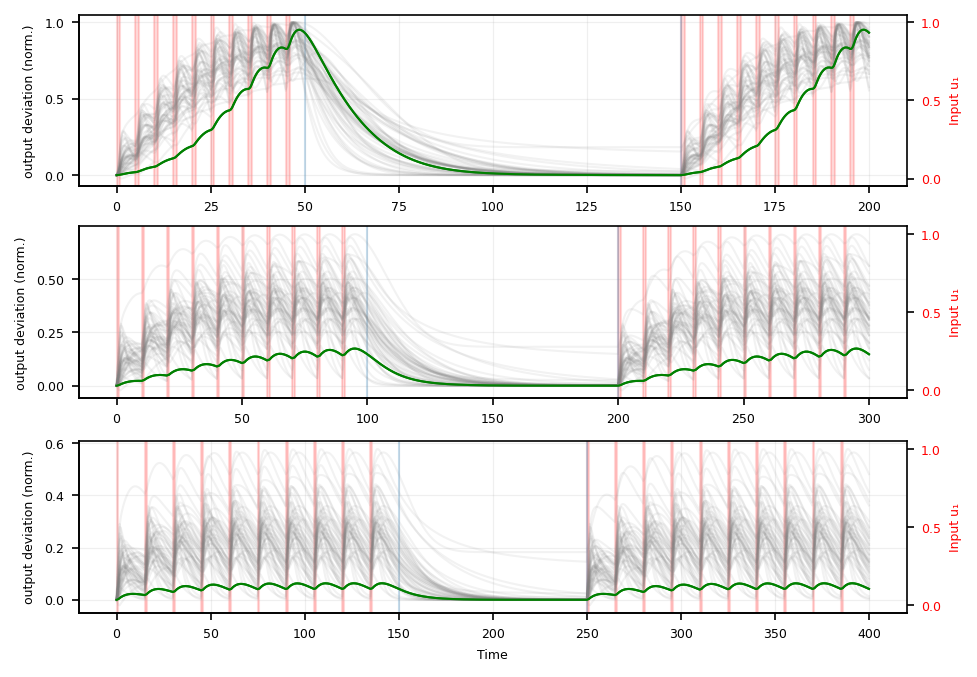

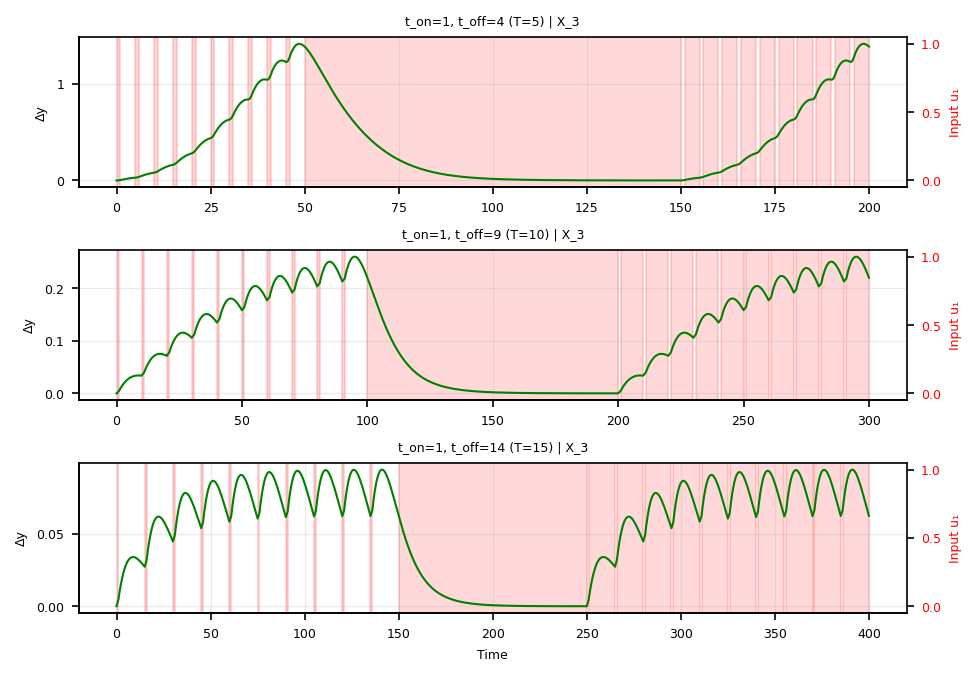

In [1]:
from RL4CRN.utils.input_interface import load_session_and_trainer

task_name = "Habituation_h3_Task_sensitization"
checkpoint_path = f"{task_name}.pkl"

trainer = load_session_and_trainer(checkpoint_path, device="cuda")

# Plot first 10 HOF entries on the same figure, but save only after the last one
fig, axes = None, None

ylabel = "output deviation (norm.)"

fin = 50
for index in range(fin):
    sol = trainer.s.mult_env.hall_of_fame[index].state

    is_last = (index == fin-1)

    if index == 0:
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=True,
            trj_color = "green",
            normalize=True,
            y_label = ylabel,
            plot_cfg={
            },
        )
    else:
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=False,
            alpha=0.1,
            trj_color = "gray",
            normalize=True,
            y_label = ylabel,
            plot_cfg ={
            }
        )

    # Save only once, after the final overlay is drawn
    if is_last:

        sol = trainer.inspect_hof(0)
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=False,
            normalize=True,
            alpha=1.0,
            y_label = ylabel,
        )

        fig.savefig("sensitization.pdf", dpi=600, bbox_inches="tight")


import matplotlib.pyplot as plt
plt.show()

HoF[0] loss: -0.11834752765044271
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(1.2253799438476562)]
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_1 ----> X_1 + X_3;  [MAK(51.82826232910156)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_1 + X_3 ----> X_3;  [MAK(0.7332110404968262)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(0.7588115334510803)]
X_3 + X_3 ----> ∅;  [MAK(5.881089210510254)]


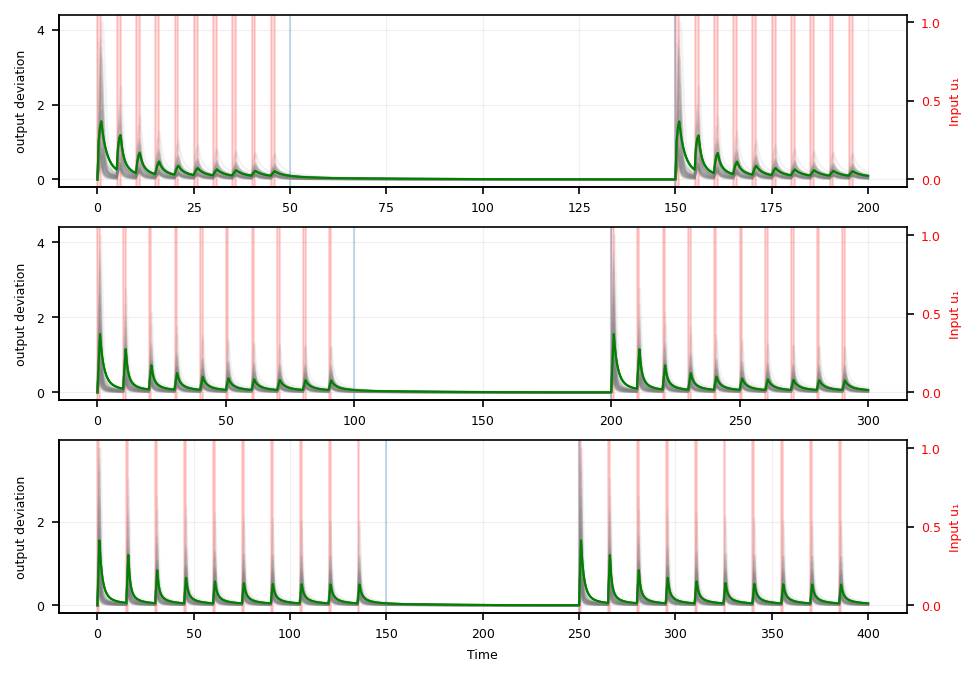

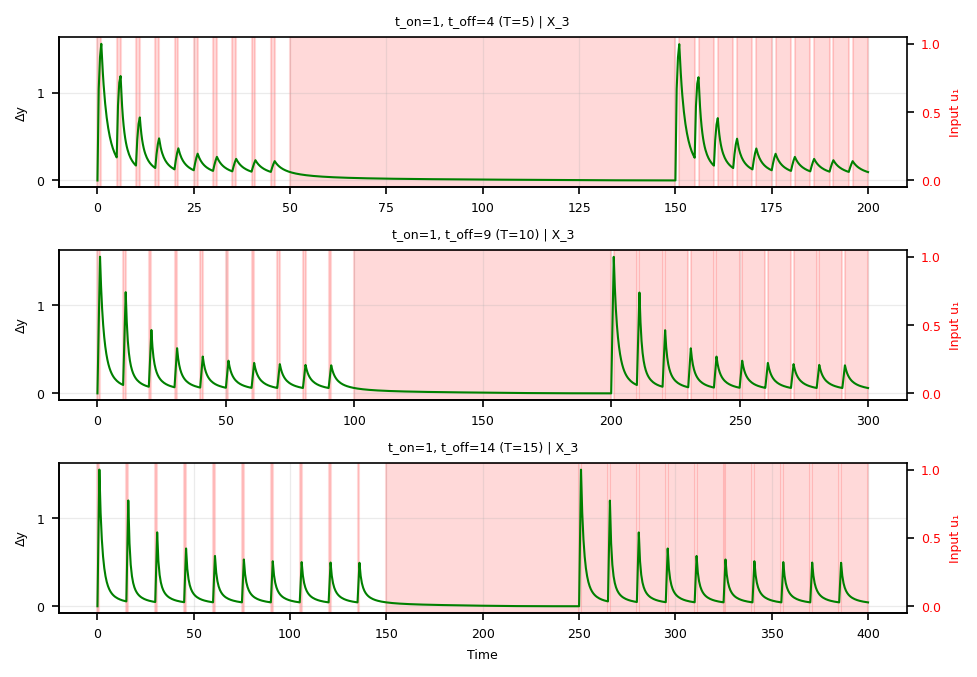

In [4]:
from RL4CRN.utils.input_interface import load_session_and_trainer

task_name = "Habituation_h3_Task"
checkpoint_path = f"{task_name}.pkl"

trainer = load_session_and_trainer(checkpoint_path, device="cuda")

# Plot first 10 HOF entries on the same figure, but save only after the last one
fig, axes = None, None

ylabel = "output deviation"

fin = 50
for index in range(fin):
    sol = trainer.s.mult_env.hall_of_fame[index].state

    is_last = (index == fin-1)

    if index == 0:
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=True,
            trj_color = "green",
            y_label = ylabel,
            plot_cfg={
            },
        )
    else:
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=False,
            alpha=0.1,
            trj_color = "gray",
            y_label = ylabel,
            plot_cfg ={
            }
        )

    # Save only once, after the final overlay is drawn
    if is_last:

        sol = trainer.inspect_hof(0)
        fig, axes = sol.plot_transient_response_piecewise(
            fig=fig,
            axes=axes,
            gap=True,
            is_main=False,
            alpha=1.0,
            y_label = ylabel,
        )

        fig.savefig("habituation.pdf", dpi=600, bbox_inches="tight")


import matplotlib.pyplot as plt
plt.show()

range(0, 50) [-0.11834752765044271, -0.09668121608323714, -0.0961555267602149, -0.09333500162695174, -0.09128744279284633, -0.08979771729063195, -0.08906246096698382, -0.08851600062736258, -0.08658508019942106, -0.08573729237509897, -0.08550683285693565, -0.08500706802435004, -0.08364581813537635, -0.08321844981558328, -0.08188062889398857, -0.08095414318949619, -0.07949306781370082, -0.07887667621347709, -0.07825129555568024, -0.07721865834383816, -0.07652726667388328, -0.07571549314116119, -0.07420328277270466, -0.07374741236549802, -0.07205869782851118, -0.06945907822142383, -0.06930049364990143, -0.06808065335373027, -0.06622206359418115, -0.065277425327346, -0.06378874689899659, -0.061450460326555684, -0.060306661379030936, -0.06001367486665141, -0.05973878827272707, -0.058926840599609426, -0.058115367408239575, -0.05782957856698016, -0.057745013036586544, -0.05744378907205335, -0.05722144722560146, -0.054646936592142835, -0.05437521278212585, -0.054223243606730885, -0.05392876027

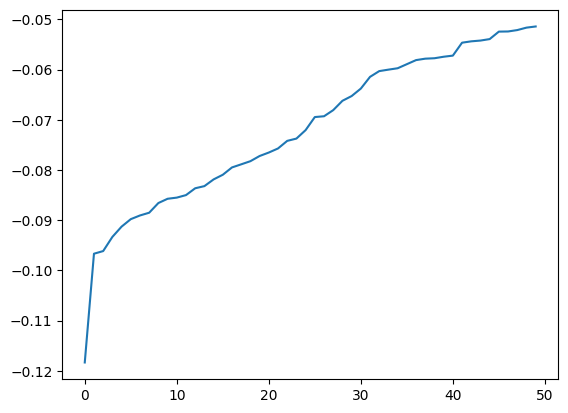

In [3]:
losses = []
for i in range(50):
    sol = trainer.s.mult_env.hall_of_fame[i].state
    losses.append(sol.last_task_info["reward"])

# flush all plots
plt.clf()
plt.plot(losses)
print(range(0,len(losses)), losses)
plt.show()